# Robust modulated-coupling iSWAP — Cubic splines

Same as `modulate_iswap.ipynb` but using `CubicSplinePulse` instead of `LinearSplinePulse`.
Controls are plotted as continuous spline curves (not just knot values).
Fidelity vs. ε sweeps for both robust and default solutions.

In [19]:
import Pkg
Pkg.activate(".")
piccolo_path = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
Pkg.develop(path=piccolo_path)
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop(path=directtrajopt_path)
Pkg.add(["CairoMakie", "Ipopt"])
Pkg.instantiate()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/mo

In [20]:
using Revise
using Piccolo
using LinearAlgebra
using Random
using Printf
using CairoMakie

## Physical parameters and operators

In [21]:
δ12 = 2π * 0.05

XX = operator_from_string("XX")
YY = operator_from_string("YY")
XY = operator_from_string("XY")
YX = operator_from_string("YX")
XI = operator_from_string("XI")
YI = operator_from_string("YI")
IX = operator_from_string("IX")
IY = operator_from_string("IY")
IZ = operator_from_string("IZ")
ZI = operator_from_string("ZI")
ZZ = operator_from_string("ZZ")

U_goal = exp(-im * π/4 * (XX + YY))

a_bound = 2π * 0.01
drive_bounds = fill(a_bound, 5)

println("δ₁₂ = ", round(δ12/(2π), digits=4), " GHz")
println("drive bound = ", round(a_bound/(2π)*1e3, digits=1), " MHz")

δ₁₂ = 0.05 GHz
drive bound = 10.0 MHz


## Hamiltonian and VariationalQuantumSystem

In [22]:
function H_nonlocal(u, t)
    g, uX1, uY1, uX2, uY2 = u
    return (
        δ12/2 * IZ
        + g * ((XX + YY) * cos(δ12 * t) + (YX - XY) * sin(δ12 * t))
        + uX1 * XI + uY1 * YI
        + uX2 * IX + uY2 * IY
    )
end

H_vars = [
    (u, t) -> ZI,
    (u, t) -> IZ,
    (u, t) -> ZZ,
]

varsys = VariationalQuantumSystem(
    H_nonlocal, H_vars, 5, drive_bounds;
    time_dependent = true
)

println("levels = ", varsys.levels, "  n_drives = ", varsys.n_drives,
        "  n_vars = ", length(varsys.G_vars), "  time_dep = ", varsys.time_dependent)

levels = 4  n_drives = 5  n_vars = 3  time_dep = true


## Robust optimization — CubicSplinePulse

In [23]:
Random.seed!(42)
n_samples = 300
T_f       = 100.0
N_knots   = 10
Δt        = T_f / N_knots

controls = 2 .* a_bound .* rand(5, n_samples) .- a_bound
times    = collect(LinRange(0.0, T_f, n_samples))

# CubicSplinePulse: initialize derivatives to zero (flat tangents)
du_init = zeros(5, n_samples)
pulse   = CubicSplinePulse(controls, du_init, times)

qcp = VariationalSplinePulseProblem(
    varsys, pulse, U_goal, N_knots;
    Q                    = 0.0,
    Q_r                  = 100.0,
    R                    = 1e-3,
    du_bound             = a_bound * 3,
    Δt_bounds            = (0.5Δt, 2Δt),
    dynamics_spline_order = 3,
    piccolo_options      = PiccoloOptions(
        timesteps_all_equal = true,
        verbose             = true,
    ),
)

push!(qcp.prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, 0.9999, get_trajectory(qcp))
)

println("\nTrajectory components: ", keys(get_trajectory(qcp).components))

    constructing VariationalSplinePulseProblem...
      pulse type: CubicSplinePulse{DataInterpolations.CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 3
      added augmented state :var_Ũ⃗  dim=128  (3 error channels)
      dynamics spline order: 3
      applying TimeStepsAllEqualConstraint

Trajectory components: (:Ũ⃗, :Δt, :t, :u, :du, :var_Ũ⃗)


In [24]:
let
    traj    = get_trajectory(qcp)
    us      = traj[:u]
    ts      = vec(traj[:t])
    iso_dim = traj.dims[:Ũ⃗]

    nominal_sys = QuantumSystem(H_nonlocal, drive_bounds; time_dependent=true)
    nlp_pulse   = LinearSplinePulse(us, ts)
    nlp_qtraj   = UnitaryTrajectory(nominal_sys, nlp_pulse, U_goal)

    Ũ⃗_init = hcat([operator_to_iso_vec(nlp_qtraj(t)) for t in ts]...)

    traj.data[traj.components[:Ũ⃗], :] .= Ũ⃗_init
    rows_var = traj.components[:var_Ũ⃗]
    traj.data[rows_var[1:iso_dim], :] .= Ũ⃗_init

    U_init = iso_vec_to_operator(Ũ⃗_init[:, end])
    F0 = abs2(tr(U_goal' * U_init)) / varsys.levels^2
    @printf("Initial fidelity (NLP-consistent init): %.4f\n", F0)
end

Initial fidelity (NLP-consistent init): 0.0976


In [25]:
log_path = joinpath(pwd(), "ipopt_cubic_robust_slow.log")
rm(log_path; force = true)

solve!(qcp;
    max_iter = 500,
    options  = IpoptOptions(eval_hessian = false, output_file = log_path),
)

if isfile(log_path)
    lines = readlines(log_path)
    print(join(lines[max(1, end-30):end], "\n"))
end

    initializing optimizer...
      building evaluator: 2 integrators, 1 nonlinear constraints
      dynamics constraints: 1440, nonlinear constraints: 1
        integrator 1 jacobian structure: 0.001s
        integrator 2 jacobian structure: 0.013s
        constraint 1 (NonlinearKnotPointConstraint) jacobian structure: 0.007s
      jacobian structure: 495392 nonzeros (0.024s)
        integrator 1 hessian structure: 0.015s
        integrator 2 hessian structure: 0.019s
        constraint 1 (NonlinearKnotPointConstraint) hessian structure: 0.002s
        computing objective hessian structure (CompositeObjective)...
          sub-objective 1 (KnotPointObjective): 0.0s
          sub-objective 2 (QuadraticRegularizer): 0.0s
          sub-objective 3 (QuadraticRegularizer): 0.0s
          sub-objective 4 (KnotPointObjective): 0.0s
          sub-objective 5 (KnotPointObjective): 0.0s
          sub-objective 6 (KnotPointObjective): 0.0s
        objective hessian structure: 0.002s
      hessia

## Default optimization — CubicSplinePulse

In [26]:
Random.seed!(42)
n_samples_def = 300
N_def         = 10
Δt_def        = T_f / N_def

controls_def = 2 .* a_bound .* rand(5, n_samples_def) .- a_bound
times_def    = collect(LinRange(0.0, T_f, n_samples_def))
du_init_def  = zeros(5, n_samples_def)
pulse_def    = CubicSplinePulse(controls_def, du_init_def, times_def)

nominal_sys = QuantumSystem(H_nonlocal, drive_bounds; time_dependent = true)
qtraj_def   = UnitaryTrajectory(nominal_sys, pulse_def, U_goal)

qcp_def = SplinePulseProblem(
    qtraj_def, N_def;
    Δt_bounds = (0.5Δt_def, 5Δt_def),
)

log_path_def = joinpath(pwd(), "ipopt_cubic_default_slow.log")
rm(log_path_def; force = true)

solve!(qcp_def;
    max_iter = 500,
    options  = IpoptOptions(eval_hessian = false, output_file = log_path_def),
)

if isfile(log_path_def)
    lines = readlines(log_path_def)
    print(join(lines[max(1, end-30):end], "\n"))
end

    constructing SplinePulseProblem with CubicSplinePulse{DataInterpolations.CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}...
    dynamics spline order: 3
	applying timesteps_all_equal constraint: Δt
    initializing optimizer...
      building evaluator: 1 integrators, 0 nonlinear constraints
      dynamics constraints: 288, nonlinear constraints: 0
        integrator 1 jacobian structure: 0.018s
      jacobian structure: 25344 nonzeros (0.02s)
        integrator 1 hessian structure: 0.001s
        computing objective hessian structure (CompositeObjective)...
          sub-objective 1 (KnotPointObjective): 0.0s
          sub-objective 2 (QuadraticRegularizer): 0.0s
          sub-objective 3 (QuadraticRegularizer): 0.0s
          sub-objective 4 (NullObjective): 0.0s
        objective hessian structure: 0.0s
      hessian structure: 27324 nonzeros (0.001s)
      linear index maps built (0.009s)
      evaluator 

## Rollout fidelities

In [27]:
traj     = get_trajectory(qcp)
traj_def = get_trajectory(qcp_def)

nominal_sys = QuantumSystem(H_nonlocal, drive_bounds; time_dependent = true)

F_robust  = unitary_rollout_fidelity(traj,     nominal_sys; interpolation = :cubic_hermite)
F_default = unitary_rollout_fidelity(traj_def, nominal_sys; interpolation = :cubic_hermite)

@printf("Robust  rollout fidelity: %.6f\n", F_robust)
@printf("Default rollout fidelity: %.6f\n", F_default)

Robust  rollout fidelity: 0.998955
Default rollout fidelity: 0.999790


## Spline control plots

Evaluate the cubic spline at fine resolution so the smooth curves are visible.

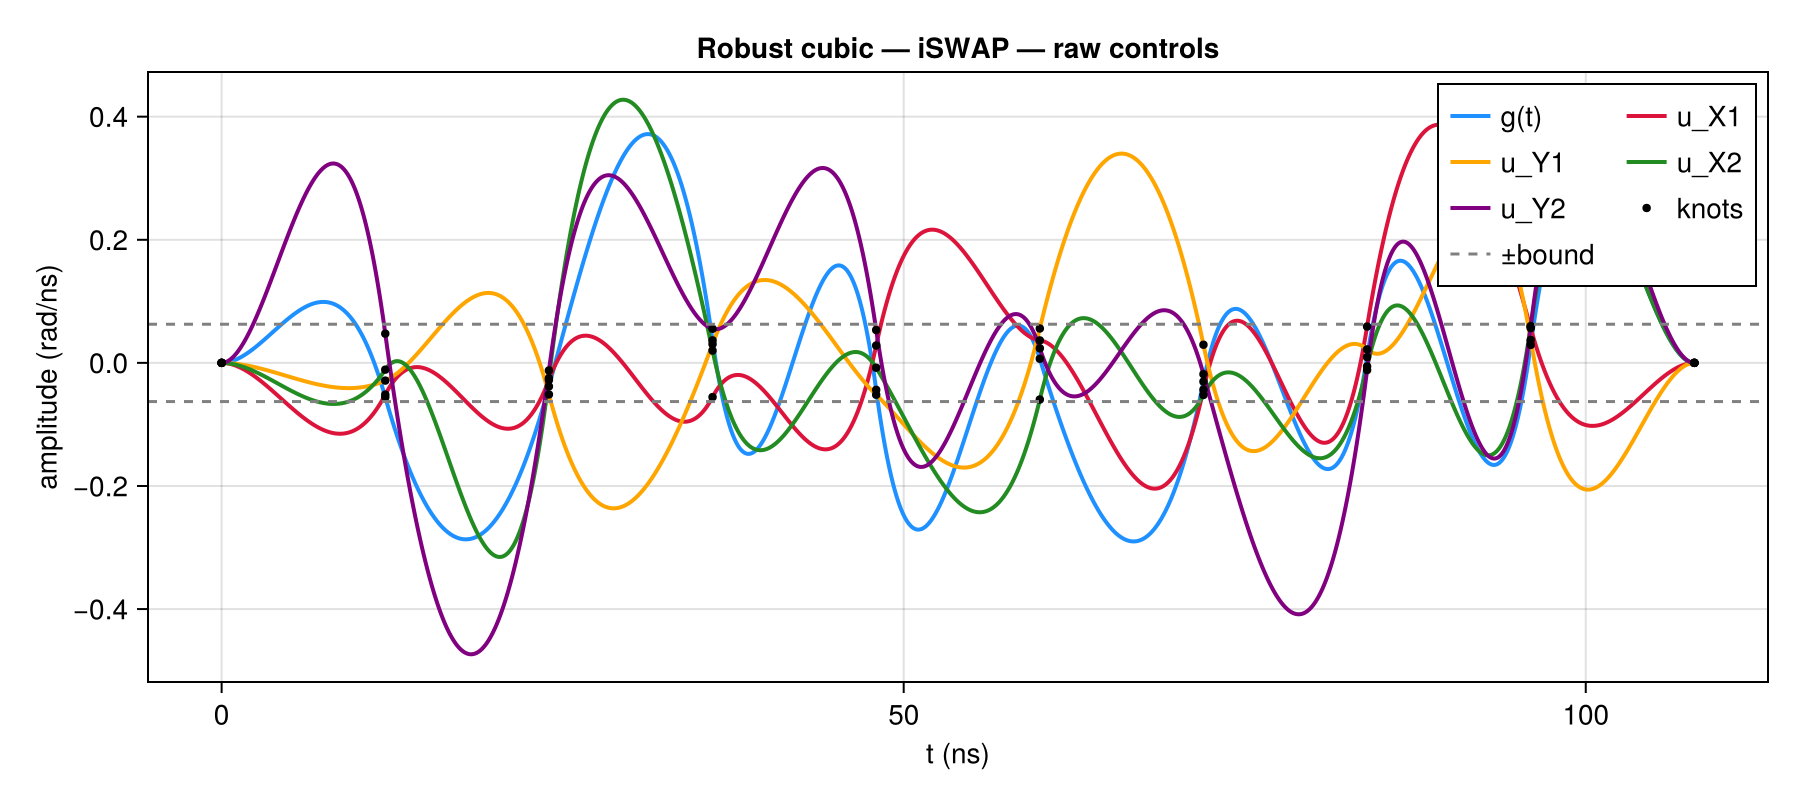

In [35]:
const KNOT_COLOR = :black
const KNOT_SIZE  = 6

function _spline_fine(traj)
    ts_knots = vec(traj[:t])
    us_knots = traj[:u]
    du_knots = traj[:du]
    pulse    = CubicSplinePulse(us_knots, du_knots, ts_knots)
    ts_fine  = collect(LinRange(ts_knots[1], ts_knots[end], 2000))
    us_fine  = sample(pulse, ts_fine)
    return ts_knots, us_knots, ts_fine, us_fine
end

function plot_raw_controls(traj, title_str)
    ts_knots, us_knots, ts_fine, us_fine = _spline_fine(traj)

    labels = ["g(t)", "u_X1", "u_Y1", "u_X2", "u_Y2"]
    colors = [:dodgerblue, :crimson, :orange, :forestgreen, :purple]

    fig = Figure(size = (900, 400))
    ax  = Axis(fig[1, 1];
        xlabel = "t (ns)", ylabel = "amplitude (rad/ns)",
        title  = title_str * " — raw controls",
    )
    for (i, (lbl, col)) in enumerate(zip(labels, colors))
        lines!(ax, ts_fine, vec(us_fine[i, :]); label = lbl, color = col, linewidth = 2)
    end
    for i in 1:5
        scatter!(ax, ts_knots, vec(us_knots[i, :]); color = KNOT_COLOR, markersize = KNOT_SIZE,
                 label = i == 1 ? "knots" : nothing)
    end
    hlines!(ax, [a_bound, -a_bound]; linestyle = :dash, color = :gray, label = "±bound")
    axislegend(ax; position = :rt, nbanks = 2)
    return fig
end

function plot_modulated_controls(traj, title_str)
    ts_knots, us_knots, ts_fine, us_fine = _spline_fine(traj)

    g_cos_fine = us_fine[1, :] .* cos.(δ12 .* ts_fine)
    g_sin_fine = us_fine[1, :] .* sin.(δ12 .* ts_fine)
    g_cos_knot = vec(us_knots[1, :]) .* cos.(δ12 .* ts_knots)
    g_sin_knot = vec(us_knots[1, :]) .* sin.(δ12 .* ts_knots)

    mod_labels = ["g·cos(δ₁₂t)", "g·sin(δ₁₂t)", "u_X1", "u_Y1", "u_X2", "u_Y2"]
    colors_mod = [:dodgerblue, :teal, :crimson, :orange, :forestgreen, :purple]
    mod_fine  = [g_cos_fine, g_sin_fine,
                 vec(us_fine[2,:]), vec(us_fine[3,:]),
                 vec(us_fine[4,:]), vec(us_fine[5,:])]
    mod_knots = [g_cos_knot, g_sin_knot,
                 vec(us_knots[2,:]), vec(us_knots[3,:]),
                 vec(us_knots[4,:]), vec(us_knots[5,:])]

    fig = Figure(size = (900, 400))
    ax  = Axis(fig[1, 1];
        xlabel = "t (ns)", ylabel = "amplitude (rad/ns)",
        title  = title_str * " — modulated",
    )
    for (lbl, col, curve) in zip(mod_labels, colors_mod, mod_fine)
        lines!(ax, ts_fine, curve; label = lbl, color = col, linewidth = 2)
    end
    for (i, kvals) in enumerate(mod_knots)
        scatter!(ax, ts_knots, kvals; color = KNOT_COLOR, markersize = KNOT_SIZE,
                 label = i == 1 ? "knots" : nothing)
    end
    hlines!(ax, [a_bound, -a_bound]; linestyle = :dash, color = :gray, label = "±bound")
    axislegend(ax; position = :rt, nbanks = 2)
    return fig
end

plot_raw_controls(get_trajectory(qcp), "Robust cubic — iSWAP")

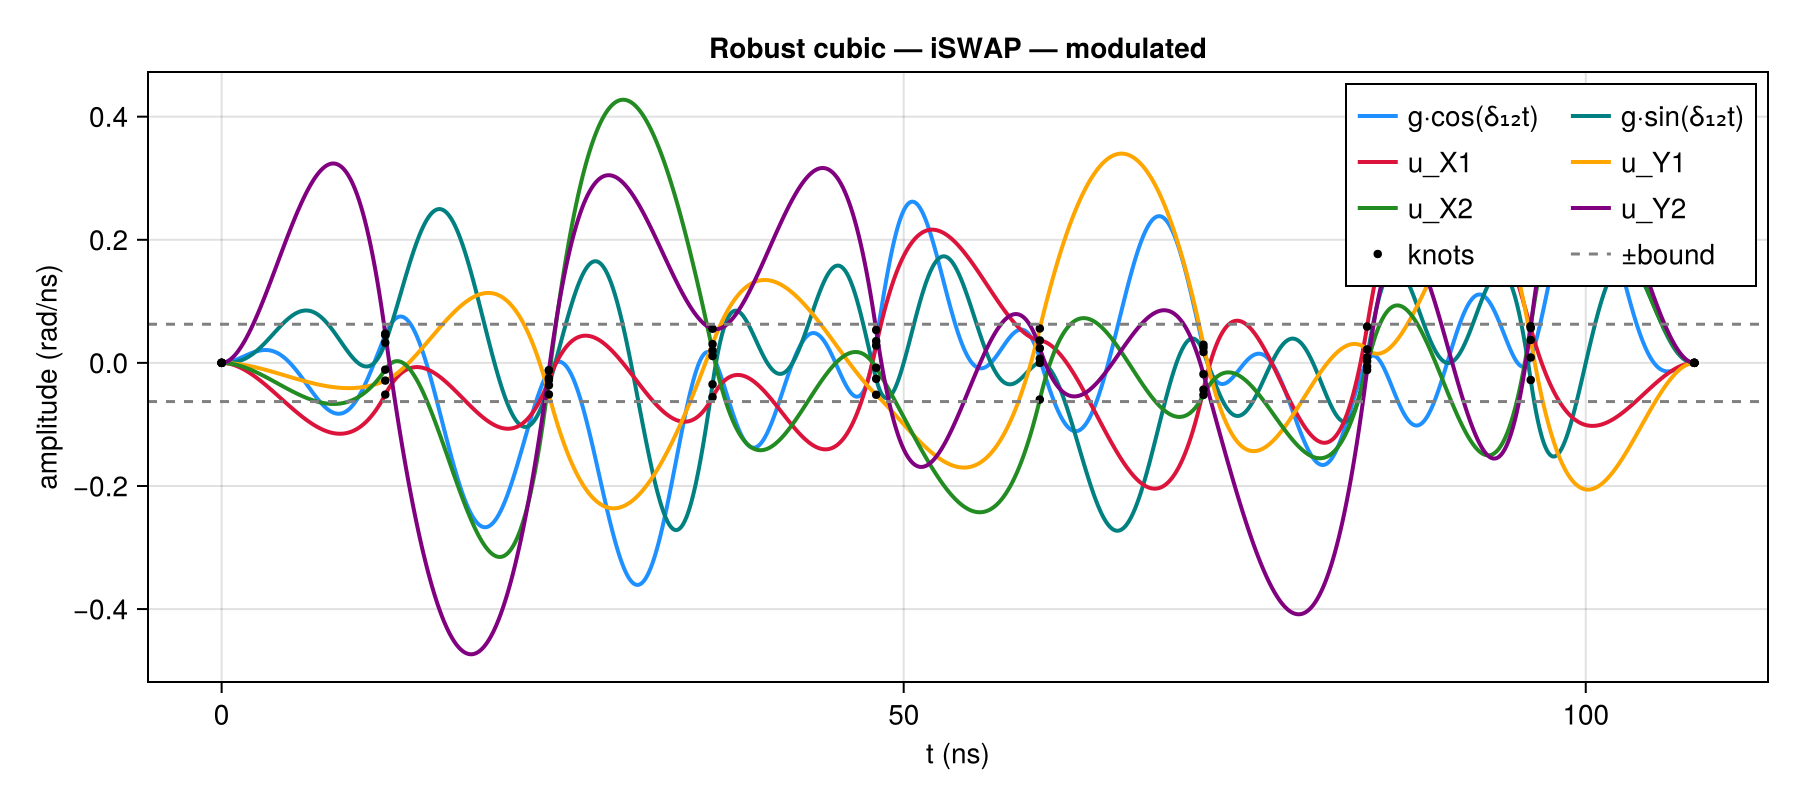

In [36]:
plot_modulated_controls(get_trajectory(qcp), "Robust cubic — iSWAP")

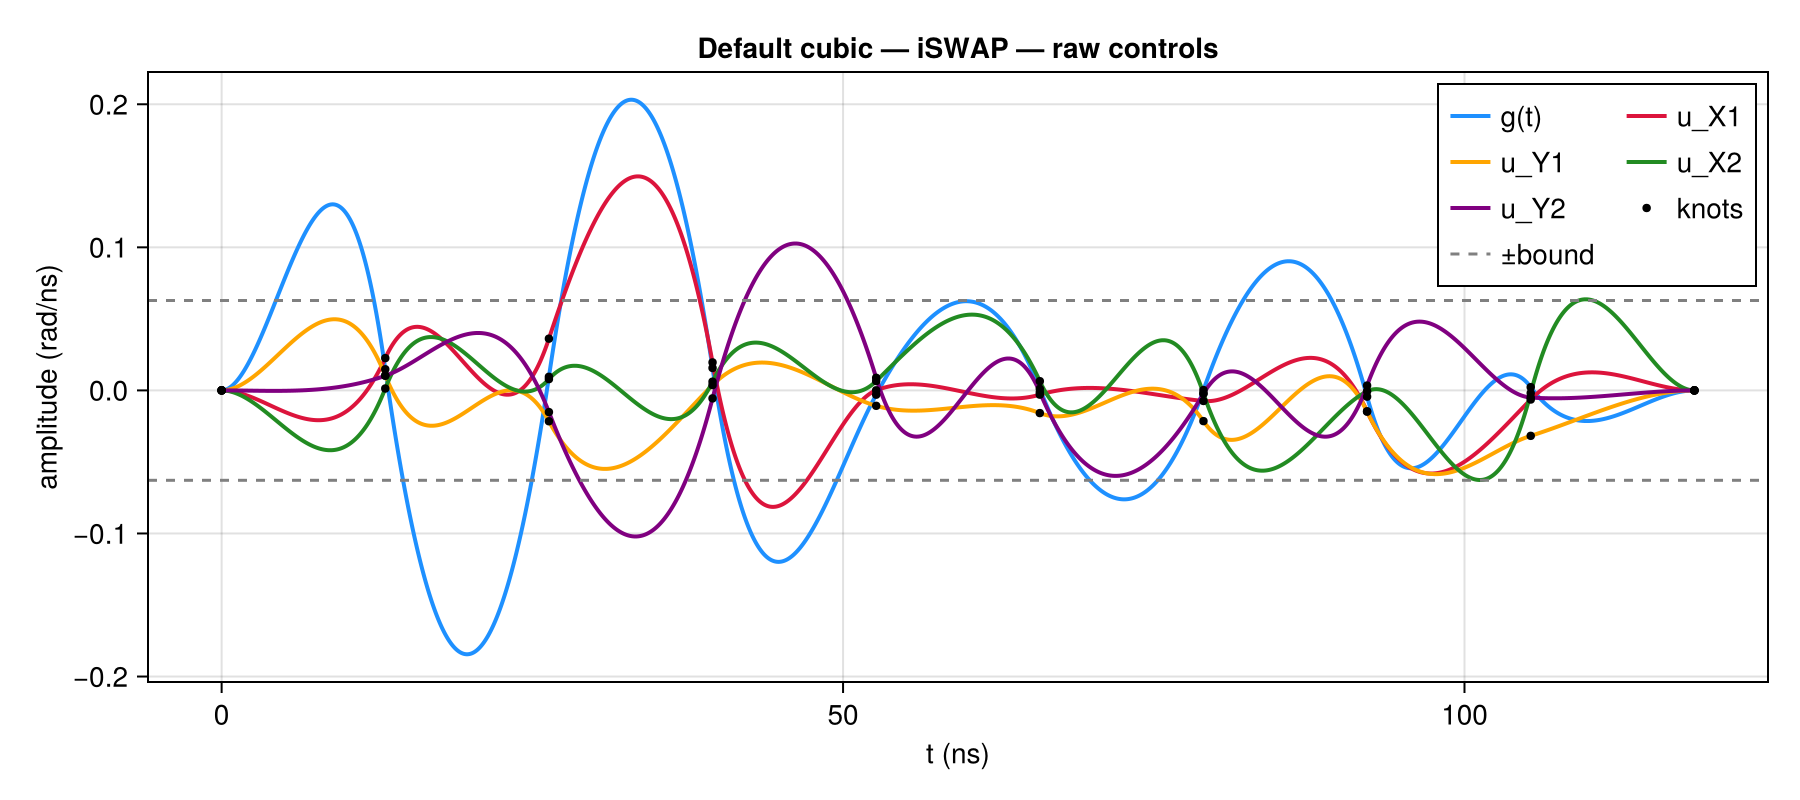

In [37]:
plot_raw_controls(get_trajectory(qcp_def), "Default cubic — iSWAP")

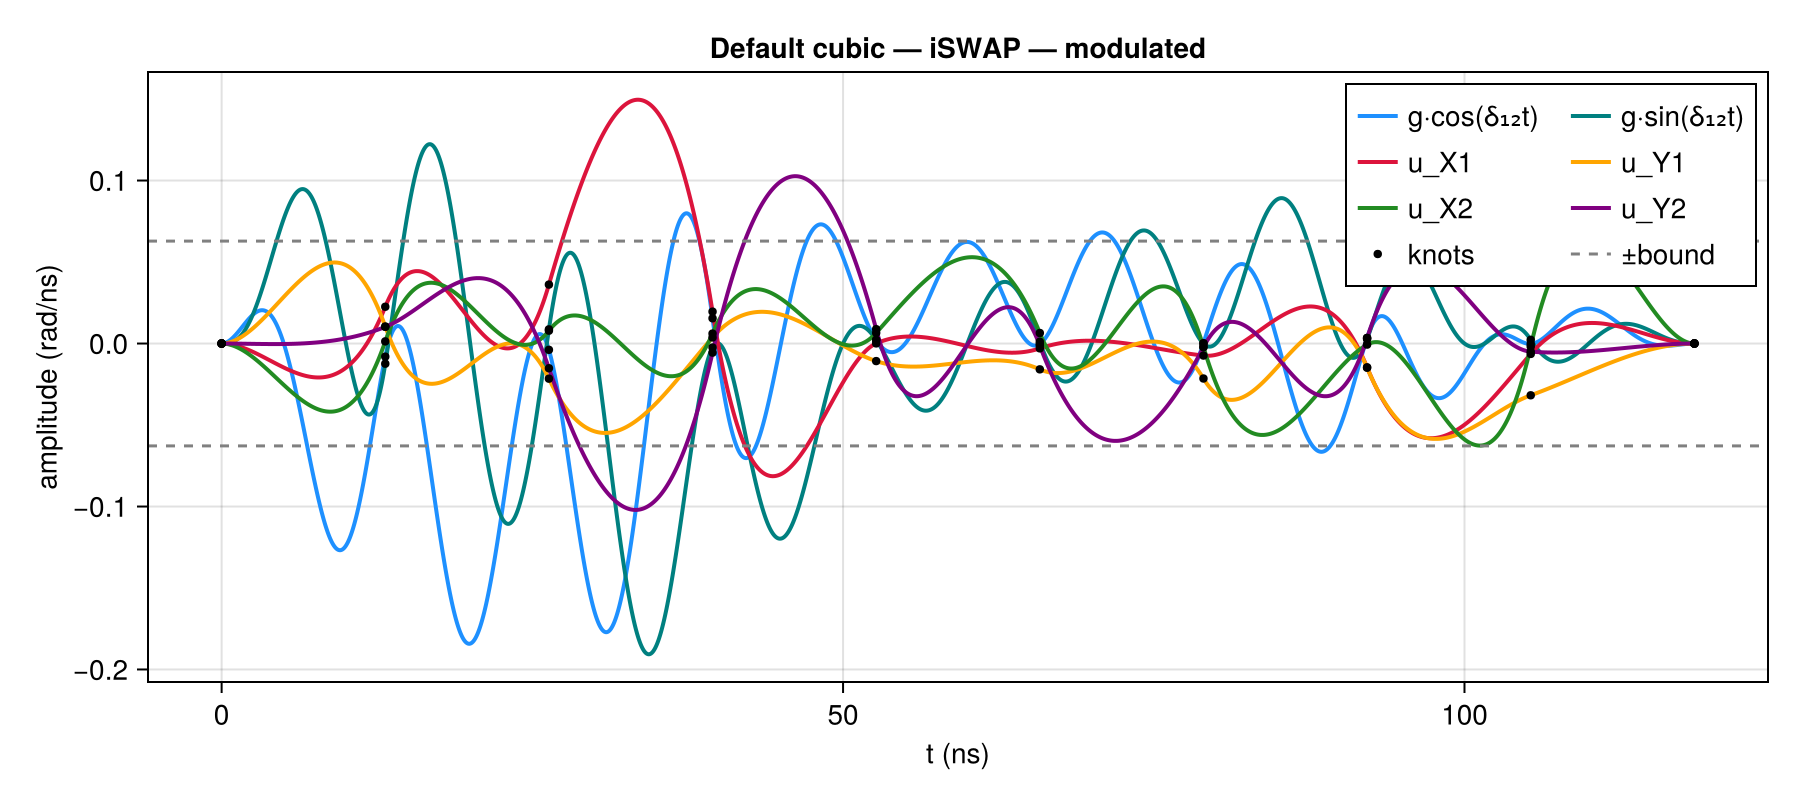

In [38]:
plot_modulated_controls(get_trajectory(qcp_def), "Default cubic — iSWAP")

## Fidelity vs. coherent error strength ε

In [32]:
function make_perturbed_sys(ε, E)
    H_p = (u, t) -> H_nonlocal(u, t) + ε * E
    return QuantumSystem(H_p, drive_bounds; time_dependent = true)
end

error_channels = [ZI, IZ, ZZ]
error_labels   = ["ZI", "IZ", "ZZ"]
εs = collect(range(-0.05, 0.05, length = 51))

fidelities = [
    [unitary_rollout_fidelity(traj, make_perturbed_sys(ε, E); interpolation = :cubic_hermite) for ε in εs]
    for E in error_channels
]

fidelities_def = [
    [unitary_rollout_fidelity(traj_def, make_perturbed_sys(ε, E); interpolation = :cubic_hermite) for ε in εs]
    for E in error_channels
]

@printf("ε=0  robust:  ZI=%.5f  IZ=%.5f  ZZ=%.5f\n",
    fidelities[1][26], fidelities[2][26], fidelities[3][26])
@printf("ε=0  default: ZI=%.5f  IZ=%.5f  ZZ=%.5f\n",
    fidelities_def[1][26], fidelities_def[2][26], fidelities_def[3][26])

ε=0  robust:  ZI=0.99896  IZ=0.99896  ZZ=0.99896
ε=0  default: ZI=0.99979  IZ=0.99979  ZZ=0.99979


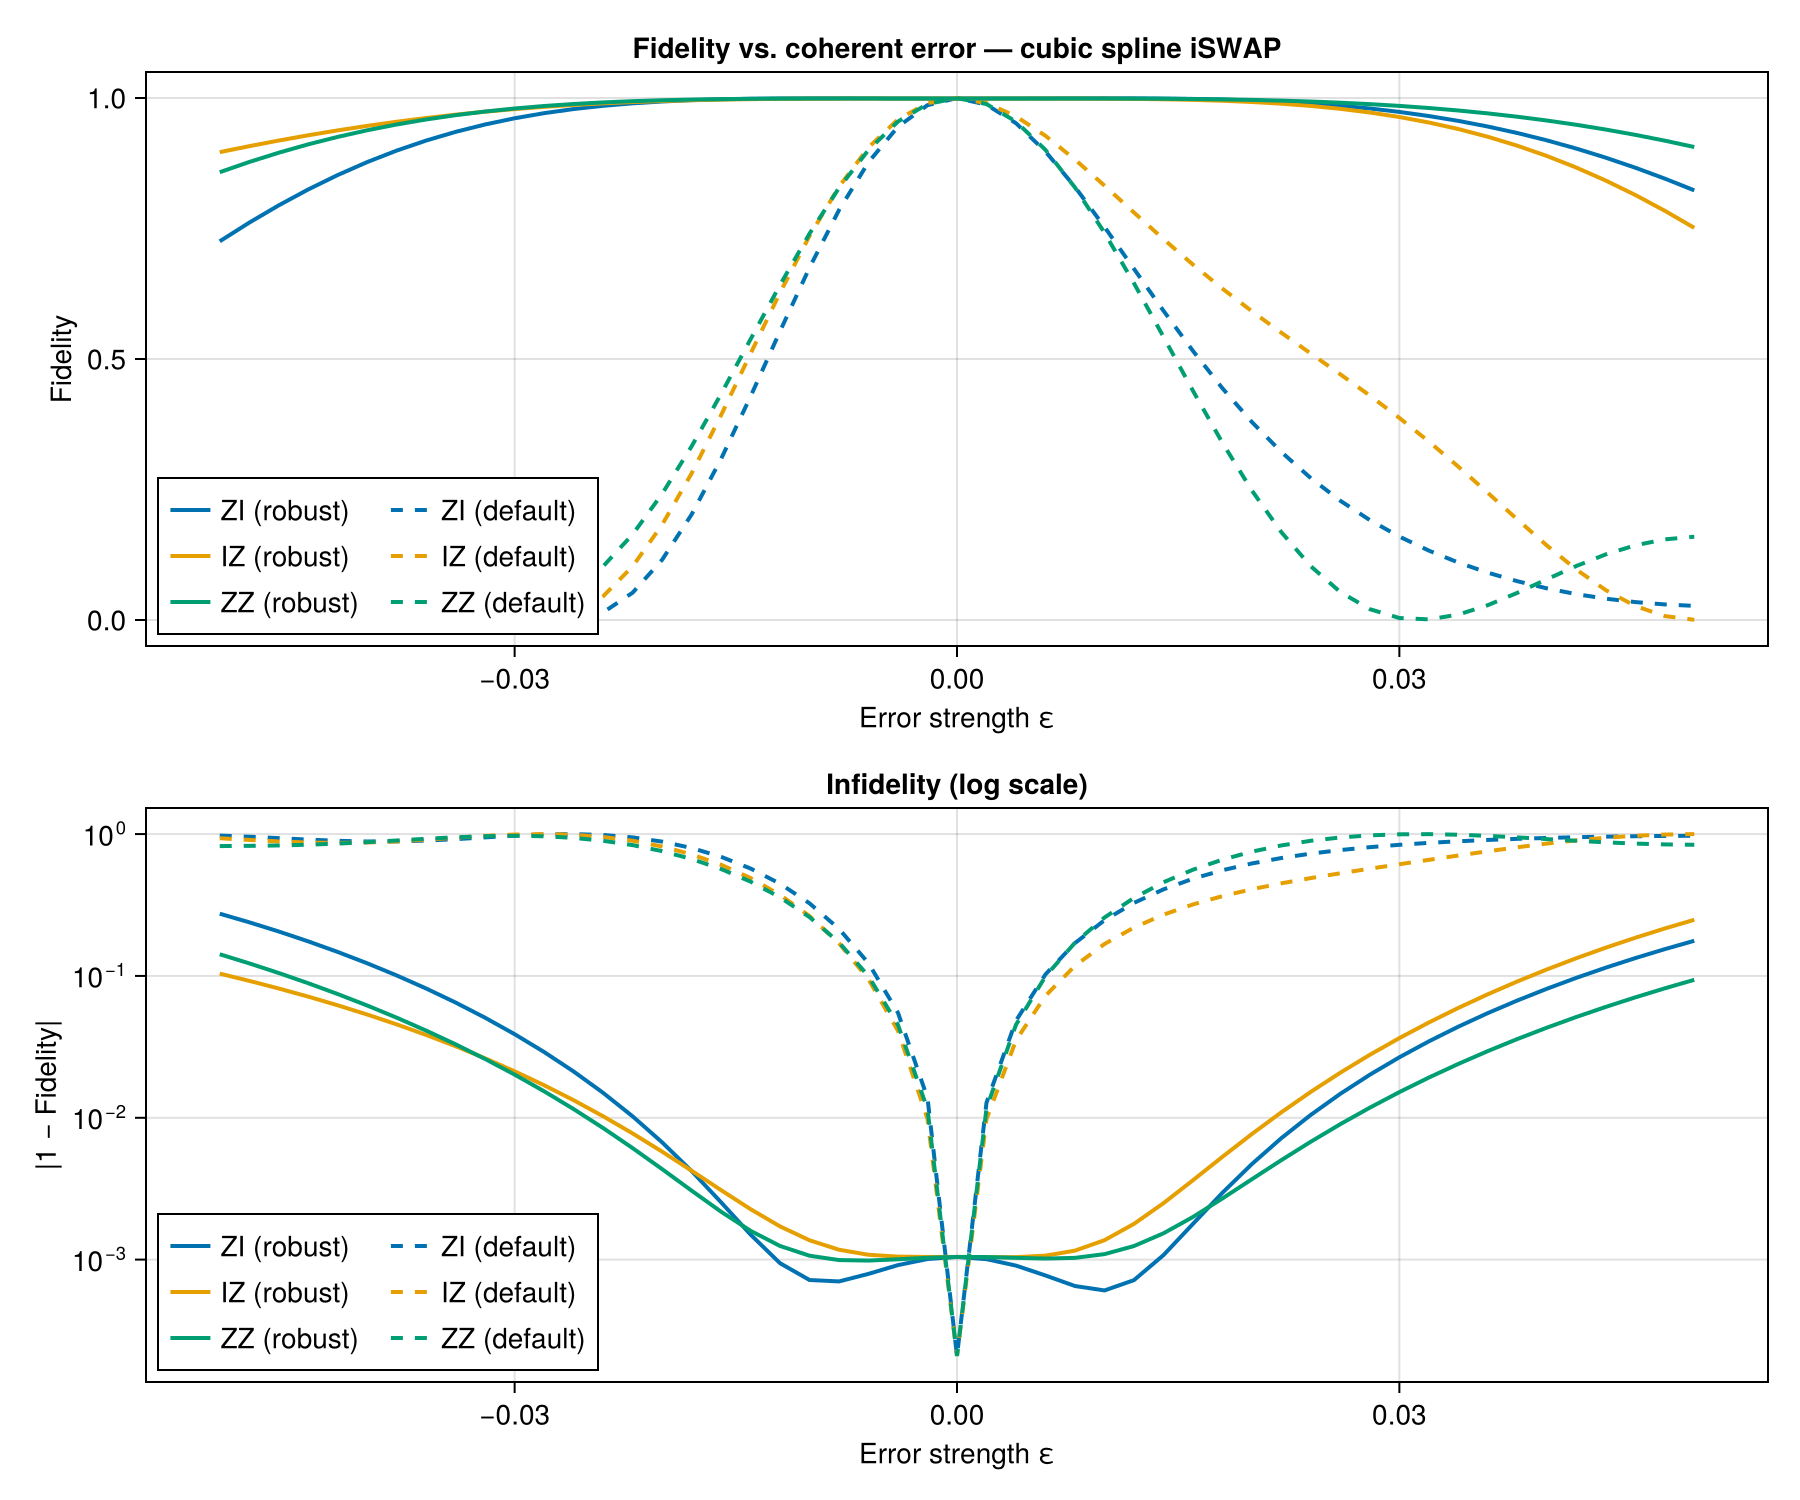

In [33]:
colors = Makie.wong_colors()

fig = Figure(size = (900, 750))

ax1 = Axis(fig[1, 1];
    xlabel = "Error strength ε",
    ylabel = "Fidelity",
    title  = "Fidelity vs. coherent error — cubic spline iSWAP",
)
for (i, (lbl, fs, fs_def)) in enumerate(zip(error_labels, fidelities, fidelities_def))
    lines!(ax1, εs, fs;     label = "$lbl (robust)",  color = colors[i], linewidth = 2, linestyle = :solid)
    lines!(ax1, εs, fs_def; label = "$lbl (default)", color = colors[i], linewidth = 2, linestyle = :dash)
end
axislegend(ax1; position = :lb, nbanks = 2)

ax2 = Axis(fig[2, 1];
    xlabel = "Error strength ε",
    ylabel = "|1 − Fidelity|",
    title  = "Infidelity (log scale)",
    yscale = log10,
)
for (i, (lbl, fs, fs_def)) in enumerate(zip(error_labels, fidelities, fidelities_def))
    lines!(ax2, εs, max.(1 .- fs,     1e-16); label = "$lbl (robust)",  color = colors[i], linewidth = 2, linestyle = :solid)
    lines!(ax2, εs, max.(1 .- fs_def, 1e-16); label = "$lbl (default)", color = colors[i], linewidth = 2, linestyle = :dash)
end
axislegend(ax2; position = :lb, nbanks = 2)

fig